In [1]:
import logging
from utility import add_project_root_to_path
import numpy as np
from copy import deepcopy

logging.basicConfig(level=logging.ERROR)

add_project_root_to_path()

In [2]:
from fee_algorithm.fixed_fee import FixedFee
from fee_algorithm.discrete_fee_perfect_oracle import DiscreteFeePerfectOracle
from fee_algorithm.based_on_trade_count_fee import BasedOnTradeCountFee
from fee_algorithm.adaptive_fee_based_on_block_price_move import (
    AdaptiveBasedOnPreviousBlockPriceMoveFee,
)
from fee_algorithm.dynamic_fee_amm_for_amm import AMMforAMMfee
from fee_algorithm.improved_fees.piecewise_fee import PiecewiseFee
from fee_algorithm.improved_fees.fixed_fee import ImprovedFixedFee

from copy import deepcopy

fee_algos_to_consider = {
    "FX_fee": FixedFee(exchange_fee_rate=0.003),
    "DA_fee": BasedOnTradeCountFee(
        a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    ),
    "BA_fee": AdaptiveBasedOnPreviousBlockPriceMoveFee(
        a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    ),
    "AMM_fee": AMMforAMMfee(
        a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    ),
    "OB_fee": DiscreteFeePerfectOracle(
        fee_rate_in_arbitrage_direction=0.0045,
        fee_rate_in_non_arbitrage_direction=0.0015,
    ),
    "IMPROVED_FX_fee": PiecewiseFee(base_algorithm=FixedFee(exchange_fee_rate=0.003)),
    "IMPROVED_DA_fee": PiecewiseFee(
        base_algorithm=BasedOnTradeCountFee(
            a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
        )
    ),
    "IMPROVED_BA_fee": PiecewiseFee(
        base_algorithm=AdaptiveBasedOnPreviousBlockPriceMoveFee(
            a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
        )
    ),
    "IMPROVED_AMM_fee": PiecewiseFee(
        base_algorithm=AMMforAMMfee(
            a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
        )
    ),
    "IMPROVED_OB_fee": PiecewiseFee(
        base_algorithm=DiscreteFeePerfectOracle(
            fee_rate_in_arbitrage_direction=0.0045,
            fee_rate_in_non_arbitrage_direction=0.0015,
        )
    ),
}

In [3]:
# Fit GBM parameters from pre-downloaded 12 s CSVs.
# Uses the first day of each monthly file (~7 200 rows) – same approach as
# fee_algorithms_comparison_synth_data.ipynb but loading from local CSVs
# instead of fetching from the Binance API.

import pandas as pd
from pathlib import Path
from experiments.experiment import GBMParameters
from experiments.synthetic_data import extract_gbm_params

DATA_DIR = Path("data/new_data")
ROWS_PER_DAY = 24 * 3600 // 12  # = 7 200

PAIRS_BY_GROUP = {
    "stable_stable": [
        ("TUSDUSDT_USDCUSDT", "TUSD/USDC"),
        ("TUSDUSDT_USDPUSDT", "TUSD/USDP"),
        ("USDCUSDT_USDPUSDT", "USDC/USDP"),
    ],
    "non_stable_stable": [
        ("USDCUSDT_RADUSDT", "USDC/RAD"),
        ("ETHUSDT_USDT", "ETH/USDT"),
        ("BTCUSDT_USDT", "BTC/USDT"),
        # # ("BTCUSDT_ETHUSDT", "BTC/ETH"),
        # # ("BTCUSDT_BNBUSDT", "BTC/BNB"),
        # # ("ETHUSDT_BNBUSDT", "ETH/BNB"),
    ],
    "non_stable_non_stable": [
        ("BTCUSDT_ETHUSDT", "ETH/BTC"),
        ("ETHUSDT_BNBUSDT", "BNB/ETH"),
        ("DOGEUSDT_BTCUSDT", "DOGE/BTC"),
    ],
}

MONTHS = ["2024-03", "2024-04", "2024-08", "2024-11"]
MONTH_ALIAS = {
    "2024-03": "volatile_market",
    "2024-04": "bear_market",
    "2024-08": "calm_market",
    "2024-11": "bull_market",
}

# gbm_params[(pair_name, month_alias)] = GBMParameters
gbm_params = {}


for group_name, pairs in PAIRS_BY_GROUP.items():
    for csv_prefix, pair_name in pairs:
        for month, month_alias in MONTH_ALIAS.items():
            csv_path = DATA_DIR / f"{csv_prefix}-12s-{month}.csv"
            if not csv_path.exists():
                print(f"WARNING: {csv_path} not found, skipping")
                continue
            df = pd.read_csv(csv_path, nrows=ROWS_PER_DAY)
            params = extract_gbm_params(
                df[["price_A", "price_B"]].transpose().to_numpy()
            )
            gbm_params[(pair_name, month_alias)] = params
            print(
                f"{pair_name} / {month_alias}: mu={params.mu}, S0={params.S0}, cov={params.cov_matrix}"
            )

TUSD/USDC / volatile_market: mu=[1.3894291755568955e-08, -2.7801097197276458e-08], S0=[0.9997, 0.9994], cov=[[6.40178670e-09 7.36924202e-11]
 [7.36924202e-11 4.72815466e-09]]
TUSD/USDC / bear_market: mu=[-6.948536070381617e-08, -5.557438829314489e-08], S0=[0.9998, 1.0], cov=[[3.12859066e-09 1.73802590e-10]
 [1.73802590e-10 4.55925641e-09]]
TUSD/USDC / calm_market: mu=[-5.557994739847391e-08, 6.941591353934919e-08], S0=[0.9999, 1.0003], cov=[[ 2.03557908e-09 -8.33442507e-12]
 [-8.33442507e-12  4.40582897e-09]]
TUSD/USDC / bull_market: mu=[5.025829141801734e-07, -1.110266273046607e-07], S0=[0.9932, 1.0013], cov=[[ 1.62746840e-09 -4.31172188e-11]
 [-4.31172188e-11  4.47210388e-09]]
TUSD/USDP / volatile_market: mu=[1.3894291755568955e-08, 3.1201498136502903e-19], S0=[0.9997, 0.9993], cov=[[ 6.40178670e-09 -6.94998408e-12]
 [-6.94998408e-12  8.51413515e-10]]
TUSD/USDP / bear_market: mu=[-6.948536070381617e-08, -9.72600461682092e-08], S0=[0.9998, 1.0001], cov=[[ 3.12859066e-09 -1.80890243e-1

In [4]:
# USDC/RAD: separate market regime dates (determined from 2025 rolling mu/sigma analysis)
# volatile_market: 2025-03-10  (sigma~0.29, wild price jump)
# calm_market:     2025-06-07  (sigma~0.03, flat)
# bull_market:     2025-07-21  (steady rise, mu>0)
# bear_market:     2025-01-08  (steady decline)

# USDC_RAD_MONTHS = {
#     "2025-03": "volatile_market",
#     "2025-01": "bear_market",
#     "2025-06": "calm_market",
#     "2025-07": "bull_market",
# }
# USDC_RAD_DAY_OFFSETS = {
#     "volatile_market": 9,  # day 10 (0-indexed: row 9*7200)
#     "bear_market": 7,  # day 8
#     "calm_market": 6,  # day 7
#     "bull_market": 20,  # day 21
# }

# pair_name = "USDC/RAD"
# csv_prefix = "USDCUSDT_RADUSDT"

# for month, month_alias in USDC_RAD_MONTHS.items():
#     csv_path = DATA_DIR / f"{csv_prefix}-12s-{month}.csv"
#     if not csv_path.exists():
#         print(f"WARNING: {csv_path} not found, skipping")
#         continue
#     day_offset = USDC_RAD_DAY_OFFSETS[month_alias]
#     start_row = day_offset * ROWS_PER_DAY
#     df = pd.read_csv(csv_path, skiprows=range(1, start_row + 1), nrows=ROWS_PER_DAY)
#     # re-read header
#     header = pd.read_csv(csv_path, nrows=0)
#     df.columns = header.columns
#     params = extract_gbm_params(df[["price_A", "price_B"]].transpose().to_numpy())
#     gbm_params[(pair_name, month_alias)] = params
#     print(
#         f"{pair_name} / {month_alias} ({month}, day {day_offset+1}): mu={params.mu}, S0={params.S0}, cov_mtrx={params.cov_matrix}"
#     )
#     print()

In [5]:
# SCALE = 100  # variance scale factor (10x std)
SCALE = 1
for key in list(gbm_params.keys()):
    p = gbm_params[key]
    gbm_params[key] = GBMParameters(
        mu=p.mu,
        S0=p.S0,
        cov_matrix=p.cov_matrix * SCALE,
    )

In [6]:
from experiments.experiment import SyntheticDataDescription
from datetime import datetime

# Time ranges: 24 hours per market condition (7 200 blocks at 12s interval)
TIME_RANGE = {
    "volatile_market": (datetime(2024, 3, 1, 12, 0, 0), datetime(2024, 3, 2, 12, 0, 0)),
    "bear_market": (datetime(2024, 4, 1, 12, 0, 0), datetime(2024, 4, 2, 12, 0, 0)),
    "calm_market": (datetime(2024, 8, 1, 12, 0, 0), datetime(2024, 8, 2, 12, 0, 0)),
    "bull_market": (datetime(2024, 11, 1, 12, 0, 0), datetime(2024, 11, 2, 12, 0, 0)),
}

# synth_desc[(pair_name, month_alias)] = SyntheticDataDescription
synth_desc = {
    (pair_name, month_alias): SyntheticDataDescription(
        gbm_parameters=gbm_params[(pair_name, month_alias)],
        start_time=TIME_RANGE[month_alias][0],
        end_time=TIME_RANGE[month_alias][1],
        candle_interval="12s",
    )
    for (pair_name, month_alias) in gbm_params
}

print(f"Synthetic data descriptions: {len(synth_desc)}")

Synthetic data descriptions: 36


In [7]:
from experiments.experiment import Experiment
from experiments.configs import DEFAULT_UNINFORMED_USERS_CONFIG
from user.informed_user import InformedUser
from experiments.run_multiple_experiments import (
    run_multiple_experiments,
    get_experiment_key,
)

# 100 seeds balances statistical robustness with run time.
# 9 pairs × 4 months × 100 seeds × 10 algos = 36 000 experiments.
# Increase to 1000 for publication-quality results (360 000 experiments, ~70 min).
random_seeds = list(range(100))

experiments_configs = {}

for fee_algo_name, fee_algo in fee_algos_to_consider.items():
    for (pair_name, month_alias), desc in synth_desc.items():
        for seed in random_seeds:
            experiments_configs[
                get_experiment_key(
                    {
                        "pair_name": pair_name,
                        "month_alias": month_alias,
                        "fee_algo_name": fee_algo_name,
                        "random_seed": str(seed),
                    }
                )
            ] = Experiment(
                data=desc,
                fee_algorithm=deepcopy(fee_algo),
                informed_user=InformedUser(),
                uninformed_users=deepcopy(DEFAULT_UNINFORMED_USERS_CONFIG),
                random_seed=seed,
                lp_metrics_price_source="pool",
                # lp_metrics_price_source="fair",
            )

print(f"Total experiments to run: {len(experiments_configs)}")

Total experiments to run: 36000


In [ ]:
experiments_results = run_multiple_experiments(
    experiments_configs,
    parallel=True,
    max_workers=12,
    return_intermediate_results=False,
)

Running Experiments:  85%|████████▍ | 30472/36000 [22:41<05:26, 16.94it/s]

In [ ]:
from visualizations.compare_fee_algoritms import get_experiments_summary_by_description

df = get_experiments_summary_by_description(experiments_results)
df

,random_seed,pair_name,month_alias,fee_algo_name,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
0,3,USDC/RAD,volatile_market,FX_fee,1062.45,275,3.77,-7997.54,732,-55.81,10106.42,23.76,-12243.18
1,6,USDC/RAD,volatile_market,FX_fee,1043.43,240,4.03,-8032.31,692,-55.98,9618.42,23.90,12688.66
2,8,USDC/RAD,volatile_market,FX_fee,871.79,234,3.59,-8739.75,751,-57.43,9576.10,24.26,1805.83
3,0,USDC/RAD,volatile_market,FX_fee,1029.53,265,3.78,-8663.93,770,-57.01,10146.93,23.91,-11599.29
4,9,USDC/RAD,volatile_market,FX_fee,953.19,248,3.68,-8176.27,723,-55.64,9774.64,24.06,24722.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,94,DOGE/BTC,bull_market,IMPROVED_OB_fee,391.55,142,2.86,-7987.32,713,-57.46,9056.76,32.81,-10237.79
7996,95,DOGE/BTC,bull_market,IMPROVED_OB_fee,519.50,147,3.49,-7994.74,721,-55.77,9670.36,33.11,-6748.79
7997,97,DOGE/BTC,bull_market,IMPROVED_OB_fee,342.95,127,2.83,-8299.76,745,-57.70,8521.09,32.16,-9251.94
7998,98,DOGE/BTC,bull_market,IMPROVED_OB_fee,462.57,132,3.42,-8096.28,715,-55.81,9136.87,32.58,-8868.41


In [ ]:
import pandas as pd
from typing import Optional


def show_stats_for_pair_alias(
    pair_name: str, month_alias: str, path_to_save: Optional[str] = None
):
    df_filtered = df[
        (df["pair_name"] == pair_name) & (df["month_alias"] == month_alias)
    ]

    grouped_stats = (
        df_filtered.drop(columns=["pair_name", "month_alias", "random_seed"])
        .groupby("fee_algo_name")
        .agg(["mean", "std"])
    )

    formatted_stats = grouped_stats.apply(
        lambda row: [
            f"{row[col, 'mean']:.2f} \u00b1 {row[col, 'std']:.2f}"
            for col in grouped_stats.columns.get_level_values(0).unique()
        ],
        axis=1,
        result_type="expand",
    )
    formatted_stats.columns = grouped_stats.columns.get_level_values(0).unique()
    print(f"\n=== {pair_name} / {month_alias} ===")
    display(formatted_stats)
    if path_to_save:
        import os

        os.makedirs(os.path.dirname(path_to_save), exist_ok=True)
        formatted_stats.to_csv(path_to_save)
    return formatted_stats

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def plot_yield_stats(
    pair_name: str, month_alias: str, fee_algos: Optional[list[str]] = None
):
    df_filtered = df[
        (df["pair_name"] == pair_name) & (df["month_alias"] == month_alias)
    ]
    fee_algos = fee_algos or list(df_filtered["fee_algo_name"].unique())
    colors = sns.color_palette("husl", len(fee_algos))

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    for color, algo_name in zip(colors, fee_algos):
        algo_df = df_filtered[df_filtered["fee_algo_name"] == algo_name]
        sns.kdeplot(
            algo_df["lp_yield"],
            ax=ax,
            label=algo_name,
            color=color,
            fill=True,
            alpha=0.3,
        )

    ax.set_xlabel("LP Yield")
    ax.set_ylabel("Density")
    ax.set_title(f"LP Yield distribution — {pair_name} / {month_alias}")
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_performance_profile(
    pair_name: str, month_alias: str, fee_algos: Optional[list[str]] = None
):
    df_filtered = df[
        (df["pair_name"] == pair_name) & (df["month_alias"] == month_alias)
    ]
    fee_algos = fee_algos or list(df_filtered["fee_algo_name"].unique())

    best_per_seed = (
        df_filtered[df_filtered["fee_algo_name"].isin(fee_algos)]
        .groupby("random_seed")["lp_yield"]
        .max()
        .reset_index()
        .rename(columns={"lp_yield": "best_lp_yield"})
    )

    merged = df_filtered.merge(best_per_seed, on="random_seed")
    merged["ratio"] = merged["best_lp_yield"] / merged["lp_yield"].replace(0, np.nan)

    tau_vals = np.linspace(1, merged["ratio"].max() + 0.1, 500)
    fig, ax = plt.subplots(figsize=(10, 6))

    colors = sns.color_palette("husl", len(fee_algos))
    for color, algo_name in zip(colors, fee_algos):
        algo_df = merged[merged["fee_algo_name"] == algo_name]
        profile = [(algo_df["ratio"] <= tau).mean() for tau in tau_vals]
        ax.plot(tau_vals, profile, label=algo_name, color=color)

    ax.set_xlabel("Performance ratio τ")
    ax.set_ylabel("Fraction of problems solved")
    ax.set_title(f"Performance profile — {pair_name} / {month_alias}")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

### Stable / Stable

#### TUSD/USDC

##### volatile_market

In [ ]:
show_stats_for_pair_alias("TUSD/USDC", "volatile_market")
plot_yield_stats("TUSD/USDC", "volatile_market")
plot_performance_profile("TUSD/USDC", "volatile_market")

##### bull_market

In [ ]:
show_stats_for_pair_alias("TUSD/USDC", "bull_market")
plot_yield_stats("TUSD/USDC", "bull_market")
plot_performance_profile("TUSD/USDC", "bull_market")

##### calm_market

In [ ]:
show_stats_for_pair_alias("TUSD/USDC", "calm_market")
plot_yield_stats("TUSD/USDC", "calm_market")
plot_performance_profile("TUSD/USDC", "calm_market")

##### bear_market

In [ ]:
show_stats_for_pair_alias("TUSD/USDC", "bear_market")
plot_yield_stats("TUSD/USDC", "bear_market")
plot_performance_profile("TUSD/USDC", "bear_market")

#### TUSD/USDP

##### volatile_market

In [ ]:
show_stats_for_pair_alias("TUSD/USDP", "volatile_market")
plot_yield_stats("TUSD/USDP", "volatile_market")
plot_performance_profile("TUSD/USDP", "volatile_market")

##### bull_market

In [ ]:
show_stats_for_pair_alias("TUSD/USDP", "bull_market")
plot_yield_stats("TUSD/USDP", "bull_market")
plot_performance_profile("TUSD/USDP", "bull_market")

##### calm_market

In [ ]:
show_stats_for_pair_alias("TUSD/USDP", "calm_market")
plot_yield_stats("TUSD/USDP", "calm_market")
plot_performance_profile("TUSD/USDP", "calm_market")

##### bear_market

In [ ]:
show_stats_for_pair_alias("TUSD/USDP", "bear_market")
plot_yield_stats("TUSD/USDP", "bear_market")
plot_performance_profile("TUSD/USDP", "bear_market")

#### USDC/USDP

##### volatile_market

In [ ]:
show_stats_for_pair_alias("USDC/USDP", "volatile_market")
plot_yield_stats("USDC/USDP", "volatile_market")
plot_performance_profile("USDC/USDP", "volatile_market")

##### bull_market

In [ ]:
show_stats_for_pair_alias("USDC/USDP", "bull_market")
plot_yield_stats("USDC/USDP", "bull_market")
plot_performance_profile("USDC/USDP", "bull_market")

##### calm_market

In [ ]:
show_stats_for_pair_alias("USDC/USDP", "calm_market")
plot_yield_stats("USDC/USDP", "calm_market")
plot_performance_profile("USDC/USDP", "calm_market")

##### bear_market

In [ ]:
show_stats_for_pair_alias("USDC/USDP", "bear_market")
plot_yield_stats("USDC/USDP", "bear_market")
plot_performance_profile("USDC/USDP", "bear_market")

### Non-stable / Stable

#### USDC/RAD

##### volatile_market


=== USDC/RAD / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,829.80 ± 91.74,207.70 ± 18.34,3.81 ± 0.21,-8263.23 ± 321.48,723.03 ± 25.68,-56.37 ± 0.80,10906.65 ± 1121.92,29.86 ± 1.61,11672.74 ± 26743.35
BA_fee,969.43 ± 113.55,245.83 ± 20.34,3.76 ± 0.17,-8246.75 ± 322.72,722.90 ± 24.82,-56.27 ± 0.97,10446.04 ± 1217.10,25.83 ± 1.94,11131.71 ± 25631.35
DA_fee,1002.84 ± 115.01,256.23 ± 22.51,3.74 ± 0.20,-8268.20 ± 314.61,723.29 ± 25.19,-56.40 ± 0.93,9432.94 ± 645.19,22.80 ± 1.40,13789.39 ± 28268.00
FX_fee,996.21 ± 111.25,254.60 ± 22.02,3.74 ± 0.19,-8257.49 ± 322.74,723.01 ± 25.08,-56.34 ± 0.88,9890.97 ± 586.83,23.98 ± 0.18,12664.79 ± 27291.97
IMPROVED_AMM_fee,829.80 ± 91.74,207.70 ± 18.34,3.81 ± 0.21,-8263.23 ± 321.48,723.03 ± 25.68,-56.37 ± 0.80,10906.65 ± 1121.92,29.86 ± 1.61,11672.74 ± 26743.35
IMPROVED_BA_fee,969.43 ± 113.55,245.83 ± 20.34,3.76 ± 0.17,-8246.75 ± 322.72,722.90 ± 24.82,-56.27 ± 0.97,10446.04 ± 1217.10,25.83 ± 1.94,11131.71 ± 25631.35
IMPROVED_DA_fee,1002.84 ± 115.01,256.23 ± 22.51,3.74 ± 0.20,-8268.20 ± 314.61,723.29 ± 25.19,-56.40 ± 0.93,9432.94 ± 645.19,22.80 ± 1.40,13789.39 ± 28268.00
IMPROVED_FX_fee,996.21 ± 111.25,254.60 ± 22.02,3.74 ± 0.19,-8257.49 ± 322.74,723.01 ± 25.08,-56.34 ± 0.88,9890.97 ± 586.83,23.98 ± 0.18,12664.79 ± 27291.97
IMPROVED_OB_fee,731.76 ± 111.34,183.45 ± 22.50,3.79 ± 0.22,-8257.78 ± 329.12,723.02 ± 25.34,-56.34 ± 0.84,11207.16 ± 944.10,33.03 ± 0.32,11758.40 ± 26887.89


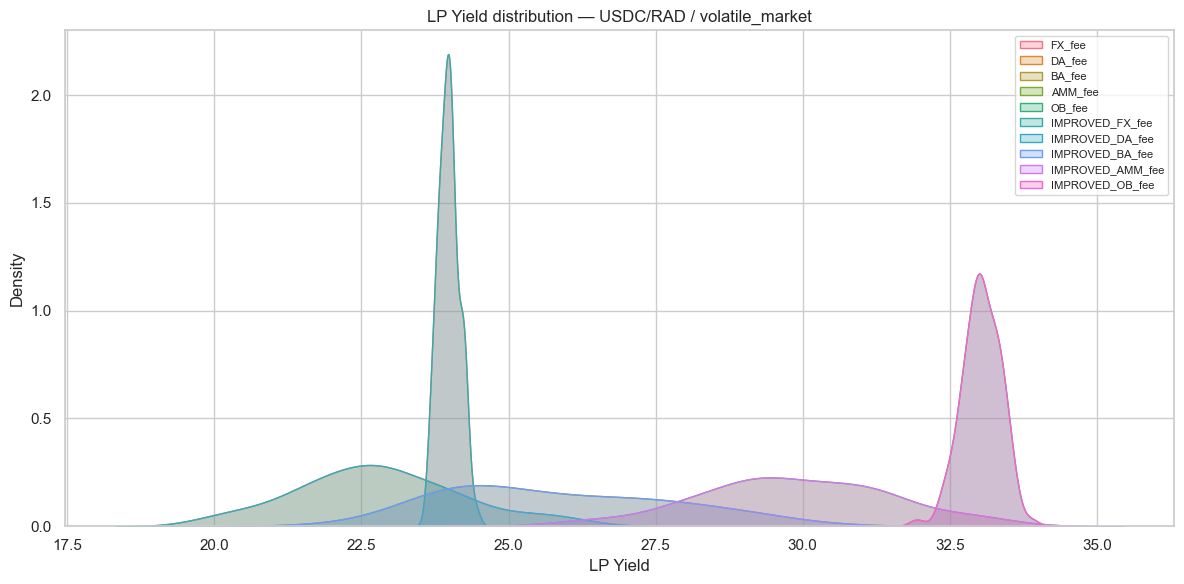

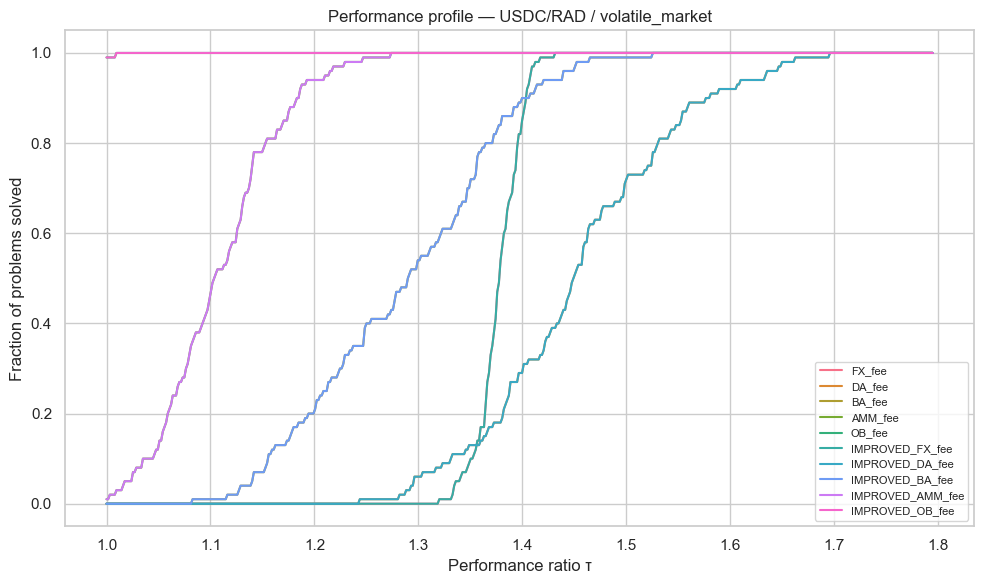

In [ ]:
show_stats_for_pair_alias("USDC/RAD", "volatile_market")
plot_yield_stats("USDC/RAD", "volatile_market")
plot_performance_profile("USDC/RAD", "volatile_market")

##### bull_market


=== USDC/RAD / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,5112.75 ± 434.11,572.24 ± 28.28,7.00 ± 0.27,-8318.40 ± 359.70,723.65 ± 24.74,-56.33 ± 1.30,24613.44 ± 2257.32,28.01 ± 1.27,35171.07 ± 83156.00
BA_fee,5963.39 ± 472.87,675.60 ± 31.24,6.94 ± 0.23,-8282.61 ± 368.82,723.19 ± 24.34,-56.11 ± 1.26,22201.46 ± 2270.62,22.03 ± 1.38,35146.54 ± 81334.97
DA_fee,6165.65 ± 509.93,700.08 ± 32.05,6.93 ± 0.24,-8296.25 ± 341.28,722.95 ± 23.78,-56.24 ± 1.35,20493.88 ± 1278.75,19.80 ± 1.24,38946.37 ± 85616.12
FX_fee,6145.48 ± 495.77,697.27 ± 31.87,6.93 ± 0.24,-8296.30 ± 350.99,723.11 ± 24.19,-56.22 ± 1.29,21150.80 ± 1154.23,20.47 ± 0.20,37322.69 ± 83831.13
IMPROVED_AMM_fee,5112.75 ± 434.11,572.24 ± 28.28,7.00 ± 0.27,-8318.40 ± 359.70,723.65 ± 24.74,-56.33 ± 1.30,24613.44 ± 2257.32,28.01 ± 1.27,35171.07 ± 83156.00
IMPROVED_BA_fee,5963.39 ± 472.87,675.60 ± 31.24,6.94 ± 0.23,-8282.61 ± 368.82,723.19 ± 24.34,-56.11 ± 1.26,22201.46 ± 2270.62,22.03 ± 1.38,35146.54 ± 81334.97
IMPROVED_DA_fee,6165.65 ± 509.93,700.08 ± 32.05,6.93 ± 0.24,-8296.25 ± 341.28,722.95 ± 23.78,-56.24 ± 1.35,20493.88 ± 1278.75,19.80 ± 1.24,38946.37 ± 85616.12
IMPROVED_FX_fee,6145.48 ± 495.77,697.27 ± 31.87,6.93 ± 0.24,-8296.30 ± 350.99,723.11 ± 24.19,-56.22 ± 1.29,21150.80 ± 1154.23,20.47 ± 0.20,37322.69 ± 83831.13
IMPROVED_OB_fee,4487.75 ± 431.96,508.75 ± 32.49,6.93 ± 0.26,-8284.34 ± 353.04,722.79 ± 24.67,-56.16 ± 1.20,26329.84 ± 1816.44,33.13 ± 0.21,34555.21 ± 83491.73


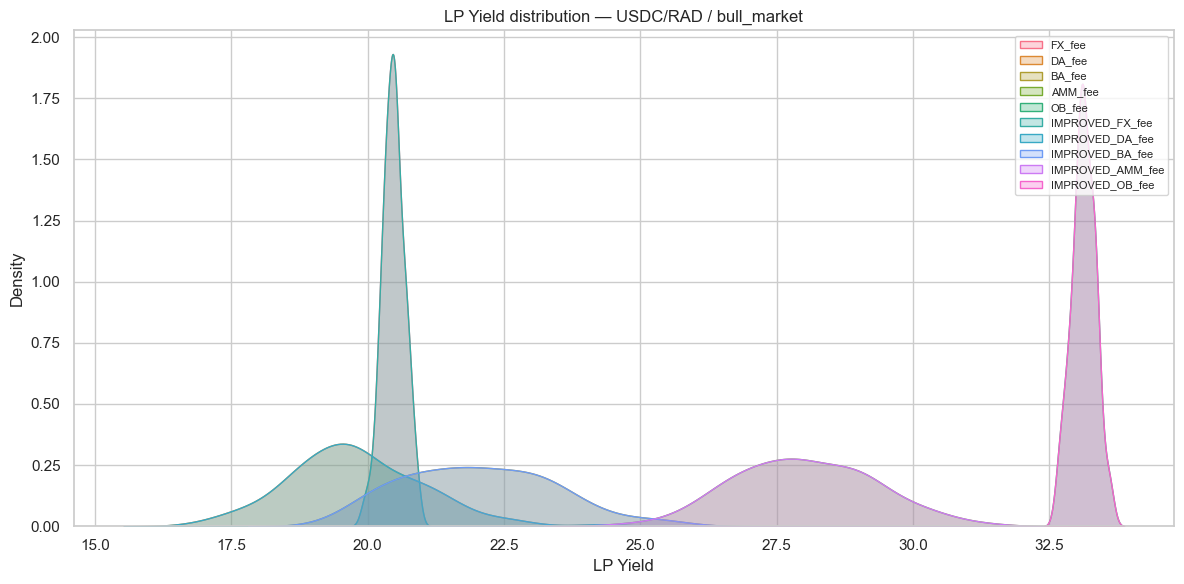

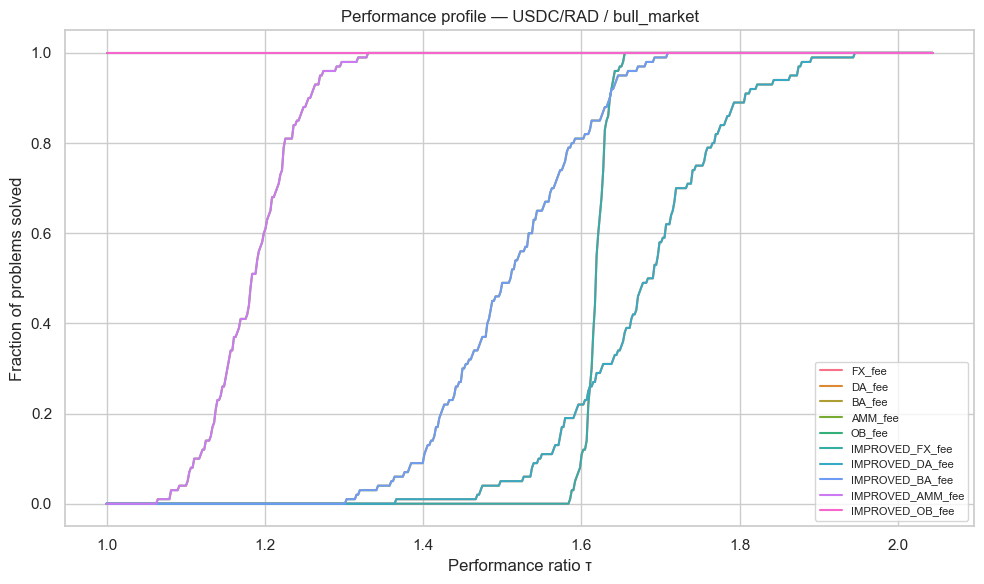

In [ ]:
show_stats_for_pair_alias("USDC/RAD", "bull_market")
plot_yield_stats("USDC/RAD", "bull_market")
plot_performance_profile("USDC/RAD", "bull_market")

##### calm_market


=== USDC/RAD / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,891.25 ± 100.17,214.96 ± 17.10,3.95 ± 0.23,-8182.08 ± 311.07,723.28 ± 24.42,-56.66 ± 0.94,10882.54 ± 975.46,29.38 ± 1.50,-2310.49 ± 14639.16
BA_fee,1044.47 ± 113.42,257.29 ± 20.16,3.88 ± 0.20,-8178.08 ± 318.01,722.51 ± 24.58,-56.69 ± 1.04,10193.27 ± 834.28,24.68 ± 1.40,-2313.04 ± 13973.73
DA_fee,1084.52 ± 116.24,268.63 ± 22.47,3.87 ± 0.20,-8195.69 ± 309.17,723.28 ± 24.94,-56.75 ± 0.93,9934.79 ± 773.72,23.41 ± 1.49,-1250.91 ± 15793.02
FX_fee,1079.10 ± 114.10,265.80 ± 22.11,3.88 ± 0.19,-8186.25 ± 303.03,723.11 ± 24.64,-56.71 ± 0.96,10037.50 ± 565.18,23.79 ± 0.18,-1720.76 ± 14934.70
IMPROVED_AMM_fee,891.25 ± 100.17,214.96 ± 17.10,3.95 ± 0.23,-8182.08 ± 311.07,723.28 ± 24.42,-56.66 ± 0.94,10882.54 ± 975.46,29.38 ± 1.50,-2310.49 ± 14639.16
IMPROVED_BA_fee,1044.47 ± 113.42,257.29 ± 20.16,3.88 ± 0.20,-8178.08 ± 318.01,722.51 ± 24.58,-56.69 ± 1.04,10193.27 ± 834.28,24.68 ± 1.40,-2313.04 ± 13973.73
IMPROVED_DA_fee,1084.52 ± 116.24,268.63 ± 22.47,3.87 ± 0.20,-8195.69 ± 309.17,723.28 ± 24.94,-56.75 ± 0.93,9934.79 ± 773.72,23.41 ± 1.49,-1250.91 ± 15793.02
IMPROVED_FX_fee,1079.10 ± 114.10,265.80 ± 22.11,3.88 ± 0.19,-8186.25 ± 303.03,723.11 ± 24.64,-56.71 ± 0.96,10037.50 ± 565.18,23.79 ± 0.18,-1720.76 ± 14934.70
IMPROVED_OB_fee,769.01 ± 103.00,190.92 ± 21.73,3.86 ± 0.22,-8181.43 ± 309.20,723.06 ± 24.67,-56.67 ± 0.81,11374.00 ± 887.80,33.09 ± 0.32,-2491.04 ± 14882.51


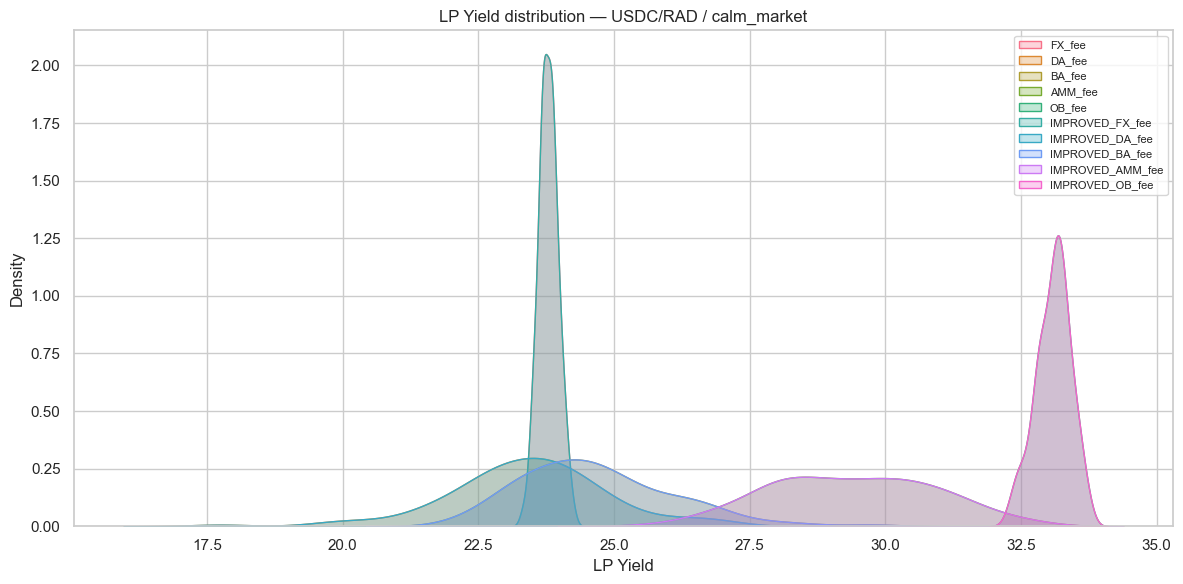

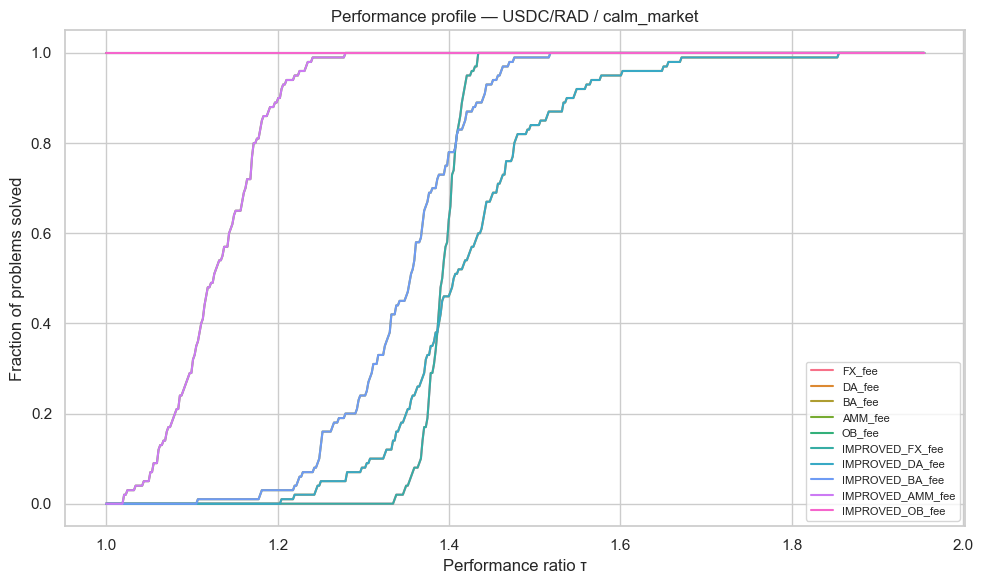

In [ ]:
show_stats_for_pair_alias("USDC/RAD", "calm_market")
plot_yield_stats("USDC/RAD", "calm_market")
plot_performance_profile("USDC/RAD", "calm_market")

##### bear_market


=== USDC/RAD / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1756.70 ± 164.81,319.41 ± 20.30,4.97 ± 0.22,-8127.33 ± 325.43,723.40 ± 24.27,-57.09 ± 1.05,14497.95 ± 1150.28,29.22 ± 1.33,6863.93 ± 34194.50
BA_fee,2075.95 ± 172.77,380.72 ± 22.96,4.93 ± 0.19,-8120.04 ± 321.45,723.05 ± 24.51,-57.08 ± 0.98,13435.28 ± 948.06,23.90 ± 1.62,6780.13 ± 33271.35
DA_fee,2144.44 ± 194.94,397.75 ± 26.42,4.89 ± 0.21,-8124.58 ± 308.74,722.68 ± 23.81,-57.14 ± 1.15,12942.81 ± 1349.48,22.30 ± 2.00,8418.08 ± 36162.81
FX_fee,2130.42 ± 190.47,394.80 ± 24.97,4.89 ± 0.20,-8115.37 ± 320.26,723.31 ± 24.57,-57.02 ± 1.09,12997.01 ± 684.20,22.52 ± 0.17,7912.36 ± 34856.52
IMPROVED_AMM_fee,1756.70 ± 164.81,319.41 ± 20.30,4.97 ± 0.22,-8127.33 ± 325.43,723.40 ± 24.27,-57.09 ± 1.05,14497.95 ± 1150.28,29.22 ± 1.33,6863.93 ± 34194.50
IMPROVED_BA_fee,2075.95 ± 172.77,380.72 ± 22.96,4.93 ± 0.19,-8120.04 ± 321.45,723.05 ± 24.51,-57.08 ± 0.98,13435.28 ± 948.06,23.90 ± 1.62,6780.13 ± 33271.35
IMPROVED_DA_fee,2144.44 ± 194.94,397.75 ± 26.42,4.89 ± 0.21,-8124.58 ± 308.74,722.68 ± 23.81,-57.14 ± 1.15,12942.81 ± 1349.48,22.30 ± 2.00,8418.08 ± 36162.81
IMPROVED_FX_fee,2130.42 ± 190.47,394.80 ± 24.97,4.89 ± 0.20,-8115.37 ± 320.26,723.31 ± 24.57,-57.02 ± 1.09,12997.01 ± 684.20,22.52 ± 0.17,7912.36 ± 34856.52
IMPROVED_OB_fee,1558.11 ± 167.18,285.47 ± 25.23,4.94 ± 0.22,-8124.30 ± 315.45,722.93 ± 25.30,-57.11 ± 0.96,15280.61 ± 1089.67,33.38 ± 0.27,6705.35 ± 35057.59


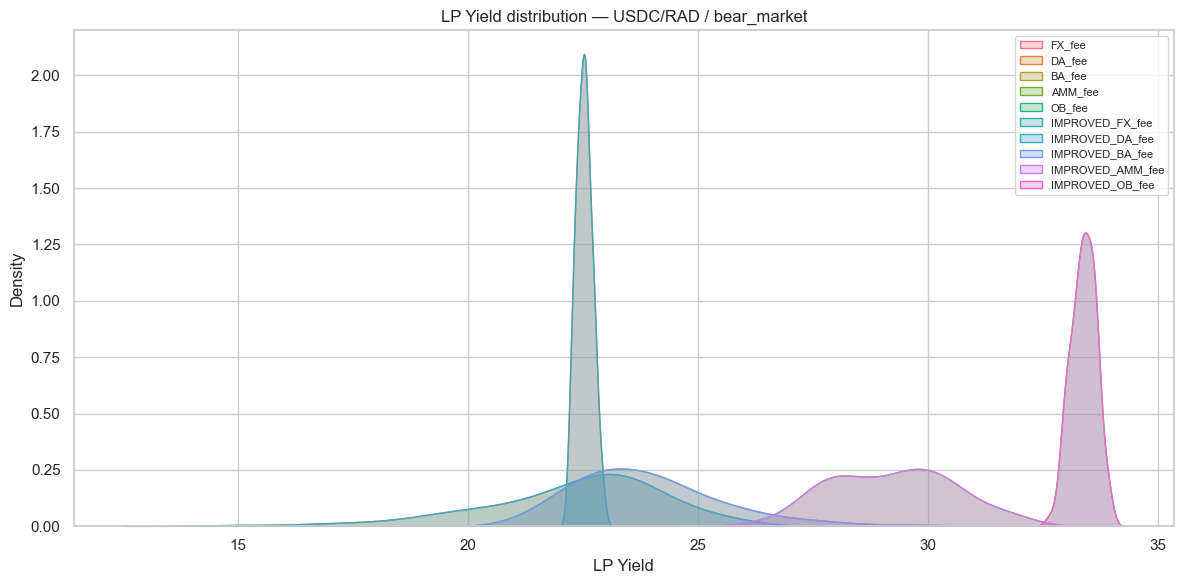

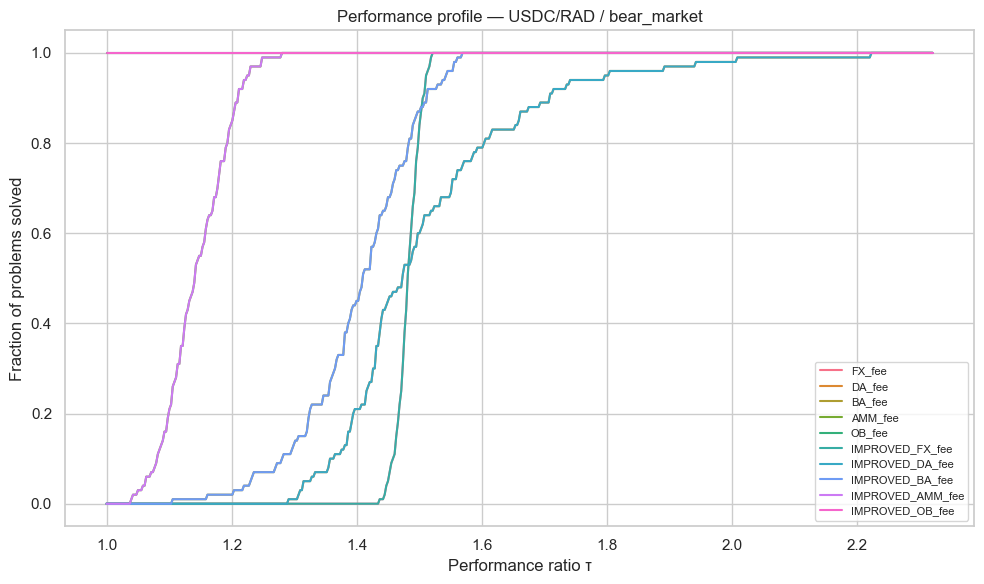

In [ ]:
show_stats_for_pair_alias("USDC/RAD", "bear_market")
plot_yield_stats("USDC/RAD", "bear_market")
plot_performance_profile("USDC/RAD", "bear_market")

#### ETH/USDT

##### volatile_market

In [ ]:
show_stats_for_pair_alias("ETH/USDT", "volatile_market")
plot_yield_stats("ETH/USDT", "volatile_market")
plot_performance_profile("ETH/USDT", "volatile_market")

##### bull_market

In [ ]:
show_stats_for_pair_alias("ETH/USDT", "bull_market")
plot_yield_stats("ETH/USDT", "bull_market")
plot_performance_profile("ETH/USDT", "bull_market")

##### calm_market

In [ ]:
show_stats_for_pair_alias("ETH/USDT", "calm_market")
plot_yield_stats("ETH/USDT", "calm_market")
plot_performance_profile("ETH/USDT", "calm_market")

##### bear_market

In [ ]:
show_stats_for_pair_alias("ETH/USDT", "bear_market")
plot_yield_stats("ETH/USDT", "bear_market")
plot_performance_profile("ETH/USDT", "bear_market")

#### BTC/USDT

##### volatile_market

In [ ]:
show_stats_for_pair_alias("BTC/USDT", "volatile_market")
plot_yield_stats("BTC/USDT", "volatile_market")
plot_performance_profile("BTC/USDT", "volatile_market")

##### bull_market

In [ ]:
show_stats_for_pair_alias("BTC/USDT", "bull_market")
plot_yield_stats("BTC/USDT", "bull_market")
plot_performance_profile("BTC/USDT", "bull_market")

##### calm_market

In [ ]:
show_stats_for_pair_alias("BTC/USDT", "calm_market")
plot_yield_stats("BTC/USDT", "calm_market")
plot_performance_profile("BTC/USDT", "calm_market")

##### bear_market

In [ ]:
show_stats_for_pair_alias("BTC/USDT", "bear_market")
plot_yield_stats("BTC/USDT", "bear_market")
plot_performance_profile("BTC/USDT", "bear_market")

### Non-stable / Non-stable

#### ETH/BTC

##### volatile_market

In [ ]:
show_stats_for_pair_alias("ETH/BTC", "volatile_market")
plot_yield_stats("ETH/BTC", "volatile_market")
plot_performance_profile("ETH/BTC", "volatile_market")

##### bull_market

In [ ]:
show_stats_for_pair_alias("ETH/BTC", "bull_market")
plot_yield_stats("ETH/BTC", "bull_market")
plot_performance_profile("ETH/BTC", "bull_market")

##### calm_market

In [ ]:
show_stats_for_pair_alias("ETH/BTC", "calm_market")
plot_yield_stats("ETH/BTC", "calm_market")
plot_performance_profile("ETH/BTC", "calm_market")

##### bear_market

In [ ]:
show_stats_for_pair_alias("ETH/BTC", "bear_market")
plot_yield_stats("ETH/BTC", "bear_market")
plot_performance_profile("ETH/BTC", "bear_market")

#### BNB/ETH

##### volatile_market

In [ ]:
show_stats_for_pair_alias("BNB/ETH", "volatile_market")
plot_yield_stats("BNB/ETH", "volatile_market")
plot_performance_profile("BNB/ETH", "volatile_market")

##### bull_market

In [ ]:
show_stats_for_pair_alias("BNB/ETH", "bull_market")
plot_yield_stats("BNB/ETH", "bull_market")
plot_performance_profile("BNB/ETH", "bull_market")

##### calm_market

In [ ]:
show_stats_for_pair_alias("BNB/ETH", "calm_market")
plot_yield_stats("BNB/ETH", "calm_market")
plot_performance_profile("BNB/ETH", "calm_market")

##### bear_market

In [ ]:
show_stats_for_pair_alias("BNB/ETH", "bear_market")
plot_yield_stats("BNB/ETH", "bear_market")
plot_performance_profile("BNB/ETH", "bear_market")

#### DOGE/BTC

##### volatile_market


=== DOGE/BTC / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,8751.38 ± 733.66,395.47 ± 34.58,13.25 ± 1.23,-8423.25 ± 355.39,723.11 ± 23.92,-55.84 ± 1.34,17410.69 ± 2864.68,21.33 ± 2.63,79171.63 ± 122846.08
BA_fee,10264.47 ± 946.78,396.48 ± 36.00,14.58 ± 1.45,-8385.19 ± 379.39,722.60 ± 24.86,-55.63 ± 1.51,14854.37 ± 3811.11,17.23 ± 3.80,79260.22 ± 120238.63
DA_fee,9528.02 ± 1177.43,438.05 ± 42.43,12.48 ± 1.49,-8389.52 ± 338.61,722.39 ± 24.11,-55.68 ± 1.39,14794.72 ± 2437.28,16.18 ± 2.56,82635.86 ± 127465.45
FX_fee,8216.21 ± 837.77,478.18 ± 72.42,10.52 ± 1.54,-8395.35 ± 340.83,722.98 ± 24.05,-55.66 ± 1.27,17321.91 ± 2132.56,18.39 ± 1.05,80131.82 ± 123397.10
IMPROVED_AMM_fee,8751.38 ± 733.66,395.47 ± 34.58,13.25 ± 1.23,-8423.25 ± 355.39,723.11 ± 23.92,-55.84 ± 1.34,17410.69 ± 2864.68,21.33 ± 2.63,79171.63 ± 122846.08
IMPROVED_BA_fee,10264.47 ± 946.78,396.48 ± 36.00,14.58 ± 1.45,-8385.19 ± 379.39,722.60 ± 24.86,-55.63 ± 1.51,14854.37 ± 3811.11,17.23 ± 3.80,79260.22 ± 120238.63
IMPROVED_DA_fee,9528.02 ± 1177.43,438.05 ± 42.43,12.48 ± 1.49,-8389.52 ± 338.61,722.39 ± 24.11,-55.68 ± 1.39,14794.72 ± 2437.28,16.18 ± 2.56,82635.86 ± 127465.45
IMPROVED_FX_fee,8216.21 ± 837.77,478.18 ± 72.42,10.52 ± 1.54,-8395.35 ± 340.83,722.98 ± 24.05,-55.66 ± 1.27,17321.91 ± 2132.56,18.39 ± 1.05,80131.82 ± 123397.10
IMPROVED_OB_fee,4123.54 ± 349.03,482.68 ± 28.93,6.70 ± 0.22,-8400.21 ± 343.38,723.02 ± 24.58,-55.69 ± 1.22,25453.08 ± 1678.61,33.21 ± 0.19,75709.01 ± 123773.15


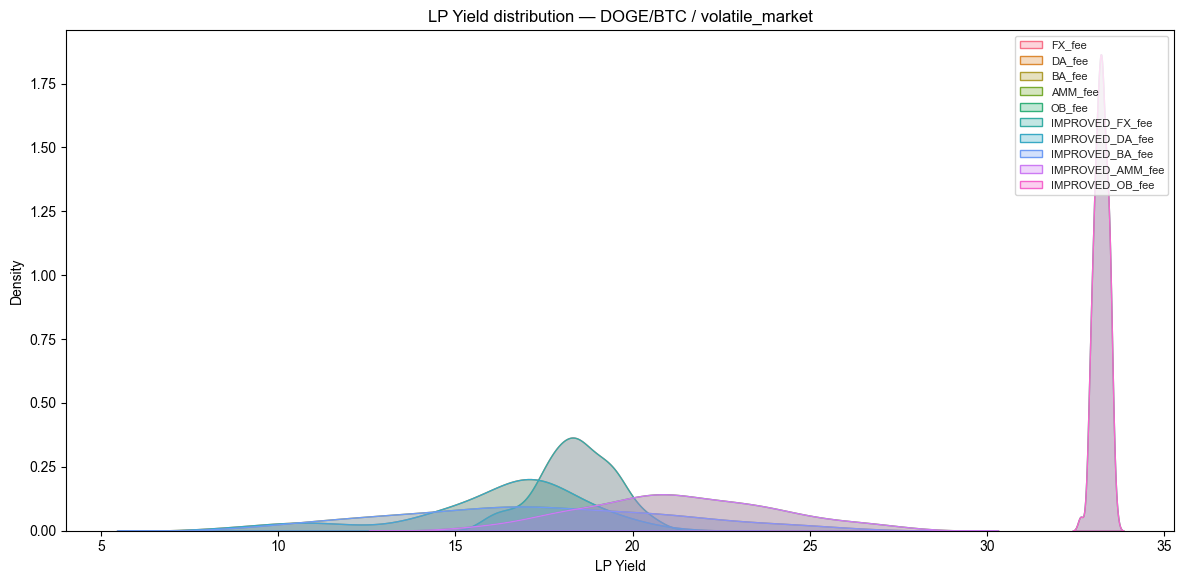

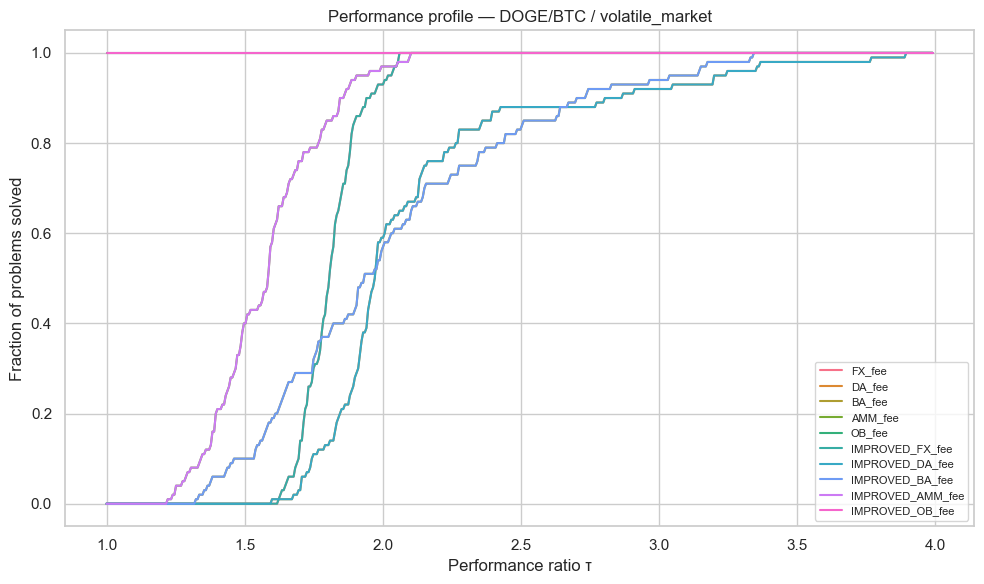

In [ ]:
show_stats_for_pair_alias("DOGE/BTC", "volatile_market")
plot_yield_stats("DOGE/BTC", "volatile_market")
plot_performance_profile("DOGE/BTC", "volatile_market")

##### bull_market


=== DOGE/BTC / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1277.37 ± 154.17,124.87 ± 15.34,8.20 ± 0.91,-8128.67 ± 310.45,723.55 ± 24.59,-56.84 ± 1.13,7872.90 ± 898.91,26.25 ± 2.12,-2136.94 ± 9946.05
BA_fee,1578.39 ± 262.99,134.12 ± 17.49,9.01 ± 1.37,-8140.58 ± 319.30,722.78 ± 24.70,-56.98 ± 1.08,7304.24 ± 901.41,22.91 ± 2.41,-2132.88 ± 9452.48
DA_fee,1394.46 ± 314.22,147.56 ± 20.93,7.50 ± 1.58,-8148.65 ± 324.13,722.70 ± 24.54,-57.05 ± 1.13,7390.74 ± 765.06,22.43 ± 1.74,-1600.21 ± 10809.71
FX_fee,815.29 ± 141.00,184.46 ± 19.64,4.16 ± 0.68,-8151.08 ± 307.40,723.29 ± 25.01,-57.02 ± 1.04,8229.20 ± 493.72,24.25 ± 0.34,-2195.37 ± 10313.89
IMPROVED_AMM_fee,1277.37 ± 154.17,124.87 ± 15.34,8.20 ± 0.91,-8128.67 ± 310.45,723.55 ± 24.59,-56.84 ± 1.13,7872.90 ± 898.91,26.25 ± 2.12,-2136.94 ± 9946.05
IMPROVED_BA_fee,1578.39 ± 262.99,134.12 ± 17.49,9.01 ± 1.37,-8140.58 ± 319.30,722.78 ± 24.70,-56.98 ± 1.08,7304.24 ± 901.41,22.91 ± 2.41,-2132.88 ± 9452.48
IMPROVED_DA_fee,1394.46 ± 314.22,147.56 ± 20.93,7.50 ± 1.58,-8148.65 ± 324.13,722.70 ± 24.54,-57.05 ± 1.13,7390.74 ± 765.06,22.43 ± 1.74,-1600.21 ± 10809.71
IMPROVED_FX_fee,815.29 ± 141.00,184.46 ± 19.64,4.16 ± 0.68,-8151.08 ± 307.40,723.29 ± 25.01,-57.02 ± 1.04,8229.20 ± 493.72,24.25 ± 0.34,-2195.37 ± 10313.89
IMPROVED_OB_fee,479.50 ± 69.07,143.83 ± 18.05,3.33 ± 0.25,-8158.09 ± 314.43,723.56 ± 25.19,-57.05 ± 0.94,9362.66 ± 714.59,32.60 ± 0.39,-2807.26 ± 10260.97


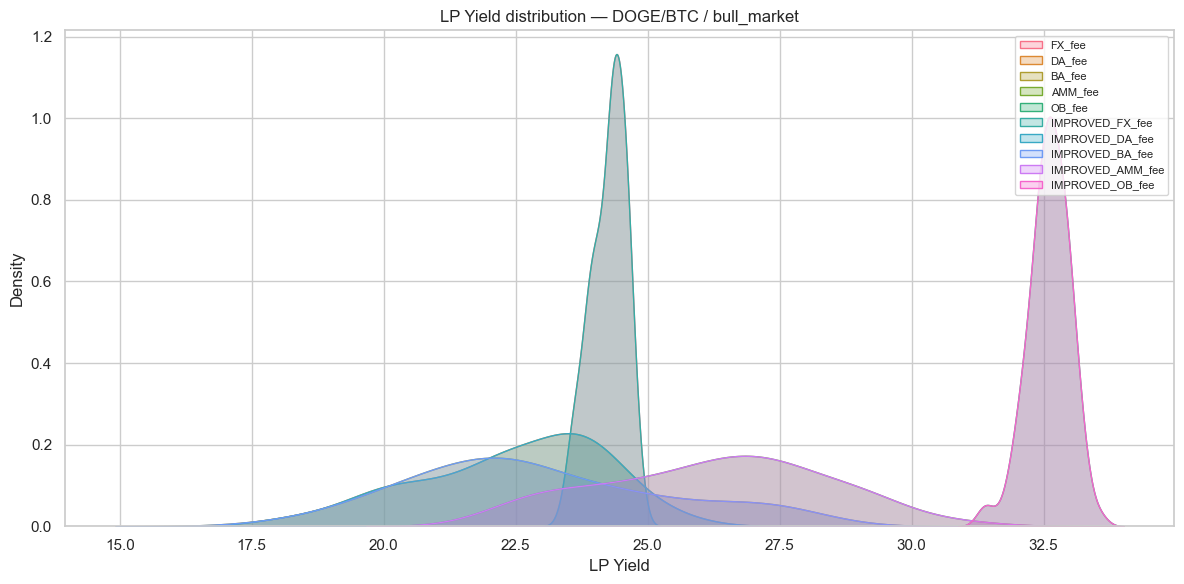

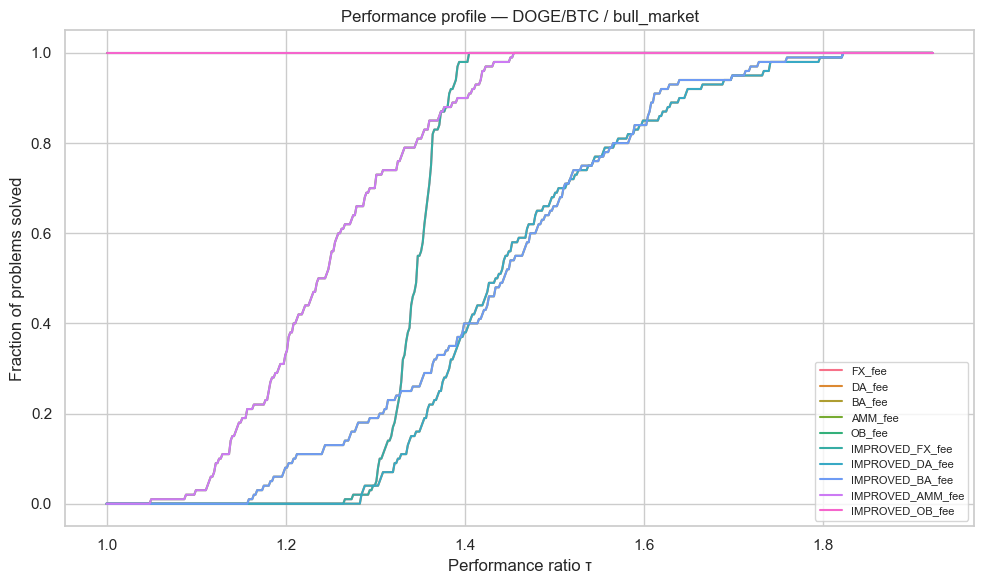

In [ ]:
show_stats_for_pair_alias("DOGE/BTC", "bull_market")
plot_yield_stats("DOGE/BTC", "bull_market")
plot_performance_profile("DOGE/BTC", "bull_market")

##### calm_market


=== DOGE/BTC / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,778.77 ± 176.61,59.45 ± 12.49,10.18 ± 2.10,-8145.21 ± 308.95,723.05 ± 24.30,-56.78 ± 1.13,5762.23 ± 633.67,26.11 ± 2.35,82.13 ± 8168.79
BA_fee,887.16 ± 252.33,60.50 ± 13.13,10.55 ± 2.38,-8183.15 ± 298.57,723.28 ± 23.50,-57.03 ± 1.19,5600.39 ± 698.39,24.65 ± 2.99,35.16 ± 8104.89
DA_fee,953.69 ± 263.13,56.52 ± 9.31,11.01 ± 2.13,-8168.21 ± 318.43,723.31 ± 24.65,-56.91 ± 1.04,5294.09 ± 514.24,23.10 ± 2.13,712.22 ± 8965.05
FX_fee,891.24 ± 153.28,53.56 ± 8.38,10.17 ± 0.64,-8166.72 ± 300.05,722.95 ± 24.45,-56.94 ± 1.07,5555.91 ± 284.85,24.06 ± 0.52,385.88 ± 8762.46
IMPROVED_AMM_fee,778.77 ± 176.61,59.45 ± 12.49,10.18 ± 2.10,-8145.21 ± 308.95,723.05 ± 24.30,-56.78 ± 1.13,5762.23 ± 633.67,26.11 ± 2.35,82.13 ± 8168.79
IMPROVED_BA_fee,887.16 ± 252.33,60.50 ± 13.13,10.55 ± 2.38,-8183.15 ± 298.57,723.28 ± 23.50,-57.03 ± 1.19,5600.39 ± 698.39,24.65 ± 2.99,35.16 ± 8104.89
IMPROVED_DA_fee,953.69 ± 263.13,56.52 ± 9.31,11.01 ± 2.13,-8168.21 ± 318.43,723.31 ± 24.65,-56.91 ± 1.04,5294.09 ± 514.24,23.10 ± 2.13,712.22 ± 8965.05
IMPROVED_FX_fee,891.24 ± 153.28,53.56 ± 8.38,10.17 ± 0.64,-8166.72 ± 300.05,722.95 ± 24.45,-56.94 ± 1.07,5555.91 ± 284.85,24.06 ± 0.52,385.88 ± 8762.46
IMPROVED_OB_fee,167.56 ± 34.27,76.75 ± 14.06,2.33 ± 0.21,-8177.81 ± 306.60,723.60 ± 25.89,-56.96 ± 0.98,6777.68 ± 471.69,31.43 ± 0.42,-264.18 ± 8528.55


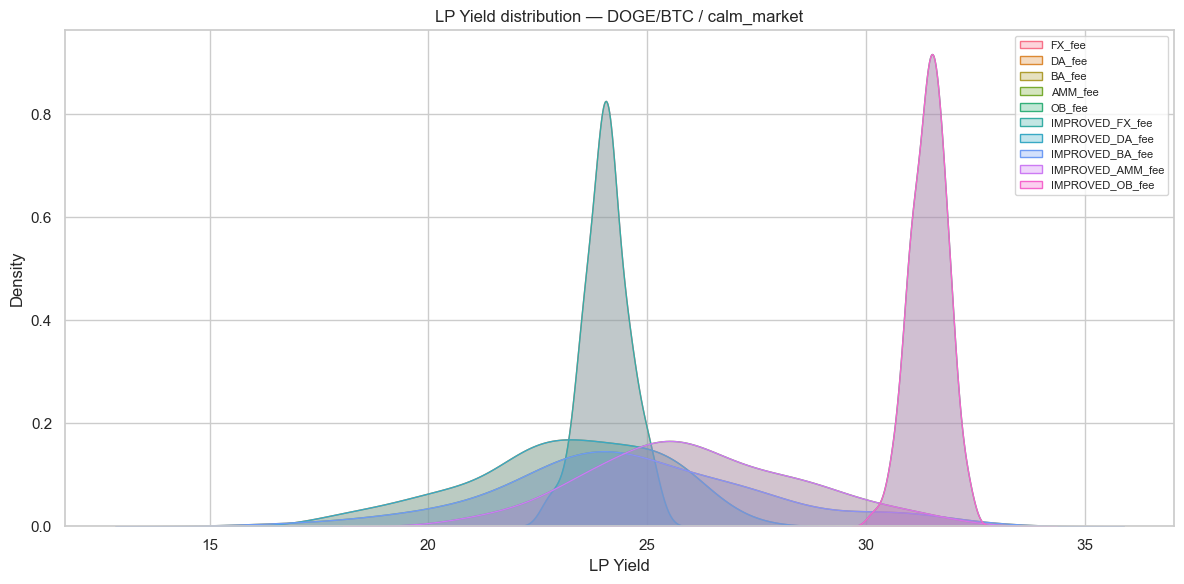

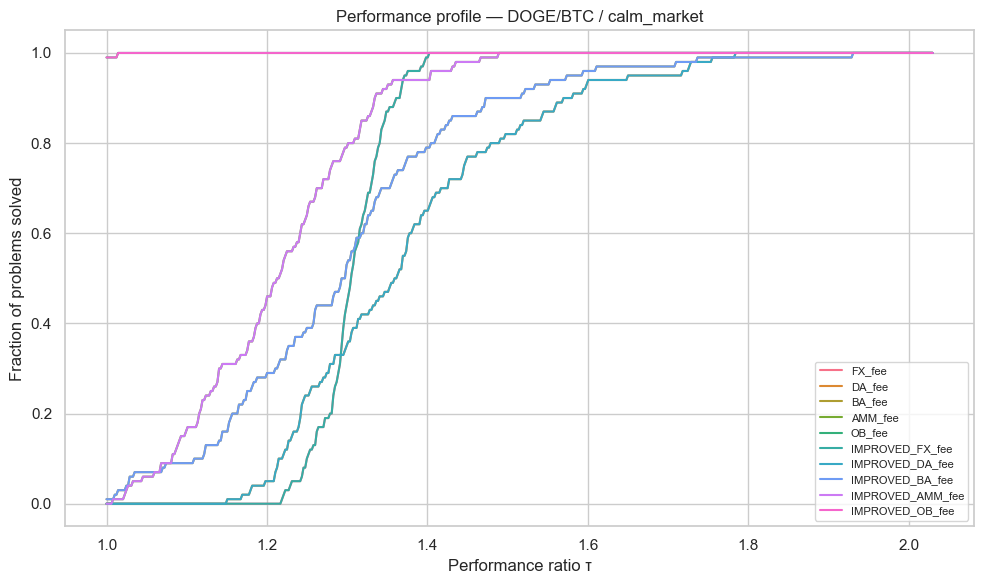

In [ ]:
show_stats_for_pair_alias("DOGE/BTC", "calm_market")
plot_yield_stats("DOGE/BTC", "calm_market")
plot_performance_profile("DOGE/BTC", "calm_market")

##### bear_market


=== DOGE/BTC / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,2412.66 ± 202.16,274.27 ± 21.00,7.18 ± 0.42,-8058.93 ± 347.92,722.94 ± 25.23,-57.37 ± 1.18,13037.50 ± 1297.74,27.31 ± 1.76,8177.34 ± 30120.64
BA_fee,2961.79 ± 408.83,306.29 ± 31.67,7.70 ± 1.11,-8068.30 ± 314.07,723.30 ± 24.02,-57.42 ± 1.22,11840.13 ± 1146.71,22.49 ± 1.84,8095.57 ± 29205.29
DA_fee,2740.71 ± 438.48,334.26 ± 30.30,6.71 ± 0.98,-8066.69 ± 325.91,722.91 ± 24.69,-57.43 ± 1.06,11457.17 ± 1175.24,20.84 ± 1.66,9792.31 ± 31461.75
FX_fee,2027.27 ± 168.14,384.11 ± 24.86,4.85 ± 0.20,-8063.35 ± 323.76,722.80 ± 24.17,-57.41 ± 1.18,12606.58 ± 676.31,22.56 ± 0.18,8606.67 ± 30505.05
IMPROVED_AMM_fee,2412.66 ± 202.16,274.27 ± 21.00,7.18 ± 0.42,-8058.93 ± 347.92,722.94 ± 25.23,-57.37 ± 1.18,13037.50 ± 1297.74,27.31 ± 1.76,8177.34 ± 30120.64
IMPROVED_BA_fee,2961.79 ± 408.83,306.29 ± 31.67,7.70 ± 1.11,-8068.30 ± 314.07,723.30 ± 24.02,-57.42 ± 1.22,11840.13 ± 1146.71,22.49 ± 1.84,8095.57 ± 29205.29
IMPROVED_DA_fee,2740.71 ± 438.48,334.26 ± 30.30,6.71 ± 0.98,-8066.69 ± 325.91,722.91 ± 24.69,-57.43 ± 1.06,11457.17 ± 1175.24,20.84 ± 1.66,9792.31 ± 31461.75
IMPROVED_FX_fee,2027.27 ± 168.14,384.11 ± 24.86,4.85 ± 0.20,-8063.35 ± 323.76,722.80 ± 24.17,-57.41 ± 1.18,12606.58 ± 676.31,22.56 ± 0.18,8606.67 ± 30505.05
IMPROVED_OB_fee,1481.33 ± 154.13,277.10 ± 25.03,4.89 ± 0.23,-8063.95 ± 313.95,722.42 ± 24.51,-57.45 ± 1.00,14767.88 ± 1030.65,33.32 ± 0.27,7482.81 ± 30217.19


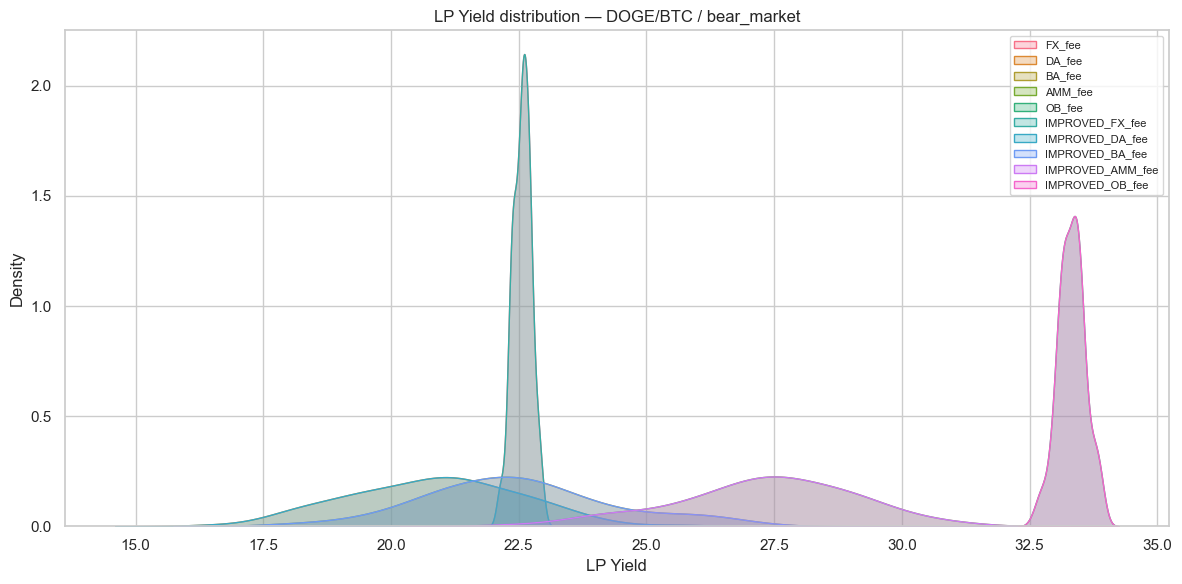

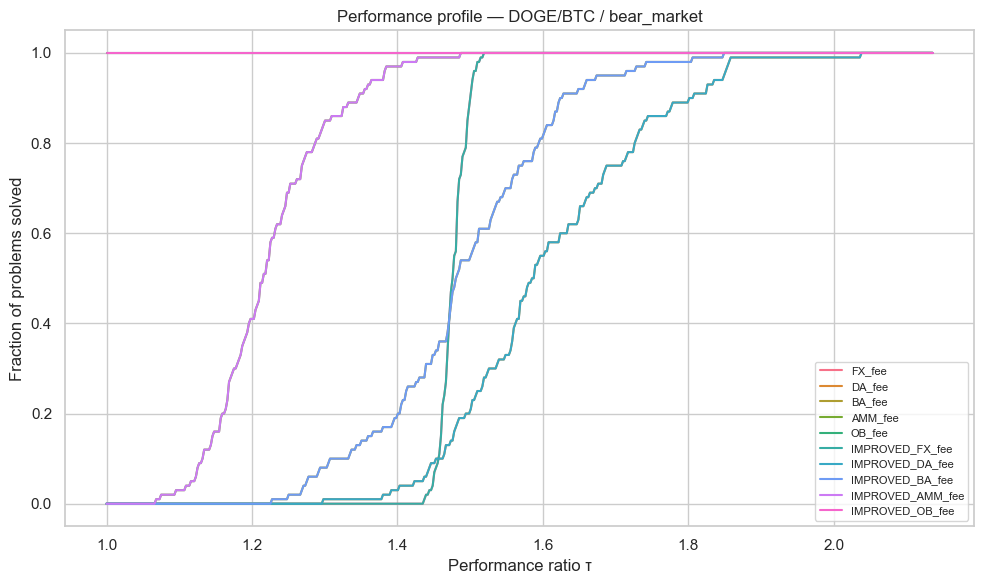

In [ ]:
show_stats_for_pair_alias("DOGE/BTC", "bear_market")
plot_yield_stats("DOGE/BTC", "bear_market")
plot_performance_profile("DOGE/BTC", "bear_market")

### Export to CSV

In [ ]:
import os

OUTPUT_DIR = "csv_export/synth_data_new_pairs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df.to_csv(f"{OUTPUT_DIR}/all_experiments_raw.csv", index=False)

for pair_name, month_alias in synth_desc.keys():
    safe_name = pair_name.replace("/", "_")
    show_stats_for_pair_alias(
        pair_name, month_alias, f"{OUTPUT_DIR}/{safe_name}_{month_alias}_stats.csv"
    )

print(f"Exported to {OUTPUT_DIR}/")